# NHANES Project
## Part 1

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


mdf = pd.read_csv('../data/linked_mortality_file_1999_2000.csv') # Load mortality file
print( mdf.head() )

#mdf columns
mdf_cols = mdf.columns.tolist()

gdf = pd.read_sas("../data/DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )

#gdf columns
gdf_cols = gdf.columns.tolist()

df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable
print( df.head() )


   SEQN  ELIGSTAT  MORTSTAT  UCOD_LEADING  DIABETES  HYPERTEN  PERMTH_INT  \
0     1         2       NaN           NaN       NaN       NaN         NaN   
1     2         1       1.0           6.0       0.0       0.0       177.0   
2     3         2       NaN           NaN       NaN       NaN         NaN   
3     4         2       NaN           NaN       NaN       NaN         NaN   
4     5         1       0.0           NaN       NaN       NaN       244.0   

   PERMTH_EXM  
0         NaN  
1       177.0  
2         NaN  
3         NaN  
4       244.0  
   SEQN  SDDSRVYR  RIDSTATR  RIDEXMON  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDAGEEX  \
0   1.0       1.0       2.0       2.0       2.0       2.0      29.0      31.0   
1   2.0       1.0       2.0       2.0       1.0      77.0     926.0     926.0   
2   3.0       1.0       2.0       1.0       2.0      10.0     125.0     126.0   
3   4.0       1.0       2.0       2.0       1.0       1.0      22.0      23.0   
4   5.0       1.0       2.0       2.

### Explain the four crucial variables

- ELIGSTAT: The ELIGSTAT variable indicates whether someone was eligible for mortality follow-up. Ineligible patients may have missing or undefined values for mortality outcomes because they were not submitted for linkage. This variable is very important for the variables MORTSTAT and PERMTH_INT because they're only meaningful for eligible participants.
- MORTSTAT: The MORTSTAT variable is the final mortality status of individual. At the end of the follow up period, individiuals are assigned either a 0, assuming they are alive through the end of the follow up, or a 1, assuming they are deceased. 
- PERMTH_INT: The PERMTH_INT variable is the Number of Person Months of Follow Up from NHANES interview date. The variable is representative of the number of months from the interview date to either the date of death, if deceased, or the end of the follow up. This variable is essentially used for modeling survival time after the interview.
- RIDAGEEX: The RIDAGEEX variable represents age, in months, at the time of their physical examination. There is another variable that represents age in years, but the RIDAGEEX variable is more precise and better for modeling risk

### Load alcohol data and start working

**Rationale for Alcohol Data**: We chose to use alcohol use data from the questionnaire data because alcohol consumption is historically linked to different types of mortality such as liver disease, cardiovascular risk, accidents, and long-term mortality. Furthermore, there are different levels of drinkers which gives us a good variation for a more precise model when predicting morality, MORTSTAT, in general as well as survival time after interview, PERMTH_INT.

In [4]:
# load alcohol questionnaire data
adf = pd.read_sas("../data/ALQ.xpt", format="xport")
print( adf.head() )

# merge alcohol questionnaire data with the previously merged data
df = df.merge(adf, on="SEQN", how="left")

df_cols = df.columns.tolist()

df.head()

   SEQN  ALQ100  ALQ110  ALQ120Q  ALQ120U  ALQ130       ALQ140Q  ALQ140U  \
0   2.0     1.0     NaN     24.0      3.0     1.0  5.397605e-79      NaN   
1   5.0     1.0     NaN      4.0      1.0     3.0  1.200000e+01      3.0   
2   7.0     2.0     2.0      NaN      NaN     NaN           NaN      NaN   
3  10.0     1.0     NaN      6.0      3.0     1.0  5.397605e-79      NaN   
4  12.0     1.0     NaN      2.0      2.0     3.0  1.000000e+00      3.0   

   ALQ150  
0     2.0  
1     2.0  
2     NaN  
3     2.0  
4     1.0  


,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,RIDRETH2,...,PERMTH_INT,PERMTH_EXM,ALQ100,ALQ110,ALQ120Q,ALQ120U,ALQ130,ALQ140Q,ALQ140U,ALQ150
0,1.0,1.0,2.0,2.0,2.0,2.0,29.0,31.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,1.0,2.0,2.0,1.0,77.0,926.0,926.0,3.0,1.0,...,177.0,177.0,1.0,NaN,24.0,3.0,1.0,5.397605e-79,NaN,2.0
2,3.0,1.0,2.0,1.0,2.0,10.0,125.0,126.0,3.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,1.0,2.0,2.0,1.0,1.0,22.0,23.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,1.0,2.0,2.0,1.0,49.0,597.0,597.0,3.0,1.0,...,244.0,244.0,1.0,NaN,4.0,1.0,3.0,1.200000e+01,3.0,2.0


### Performing Basic Exploratory Data Analysis and Visualization

In [5]:
# get the shape of the merged dataframe
print(f"Shape of merged dataframe: {df.shape}\n")

# check for missing values in the merged dataframe
missing_values = df.isnull().sum()
total_missing = missing_values.sum()
print(f"Total missing values in merged dataframe: {total_missing}")
print("\nMissing values in each column:")
print(missing_values)

#check if mortstat and permth_int having missing values
print("\nMissing values in MORTSTAT and PERMTH_INT:")
print(df[['MORTSTAT', 'PERMTH_INT']].isna().sum())

Shape of merged dataframe: (9965, 159)

Total missing values in merged dataframe: 183392

Missing values in each column:
SEQN           0
SDDSRVYR       0
RIDSTATR       0
RIDEXMON     683
RIAGENDR       0
            ... 
ALQ120U     7314
ALQ130      7309
ALQ140Q     7309
ALQ140U     8986
ALQ150      6446
Length: 159, dtype: int64

Missing values in MORTSTAT and PERMTH_INT:
MORTSTAT      4520
PERMTH_INT    4520
dtype: int64


### Document the missing data
-   The merged dataframe has 9,965 rows and 159 columns, resulting in 183,392 missing values, which is approximately 15.5% of the total data. 
-   Many alcohol (ALQ) variables are going to be missing. This is largely due to NHANES survey design: alcohol questions were only asked of participants aged 20 and older, and follow-up questions were skipped for respondents who reported being non-drinkers.
-   The mortality variables, MORTSTAT and PERMTH_INT, have 4,520 missing values each. This missingness may be due to incomplete linkage in the mortality file. For now, we document it, but it will need to be addressed in modeling.
- Since alcohol data are only meaningful for adults (20+), we will keep all ages for this EDA to explore missingness and distributions. Restricting to 20+ will be done later when building the kNN models.

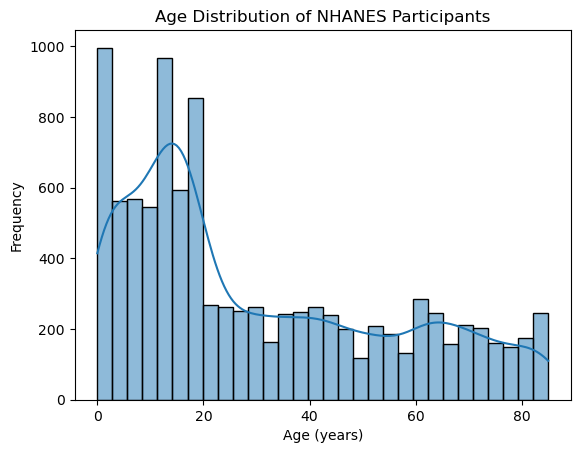

In [6]:
#  check age distribution
sns.histplot(df['RIDAGEYR'], bins=30, kde=True)
plt.title('Age Distribution of NHANES Participants')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.show()


We look at age distribution just to get a sense of frequency of different age groups and there is high frequency for ages before 20. This shows we'll be losing that much data later on when we focus on our kNN which will have to be with adults 20 and older

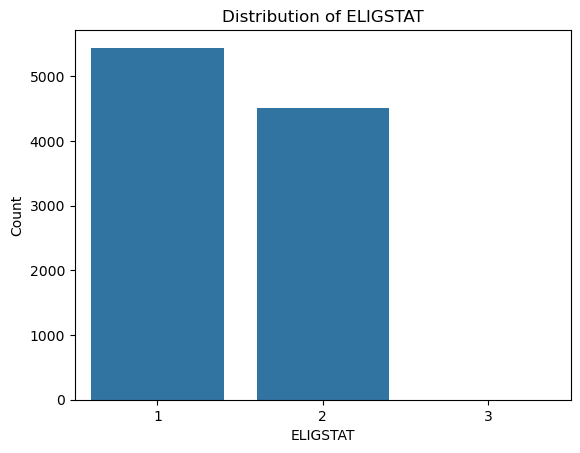

ELIGSTAT
1    5445
2    4517
3       3
Name: count, dtype: int64


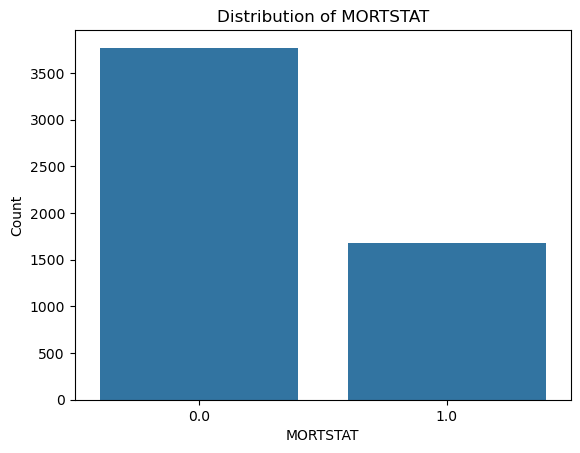

MORTSTAT
NaN    4520
0.0    3770
1.0    1675
Name: count, dtype: int64


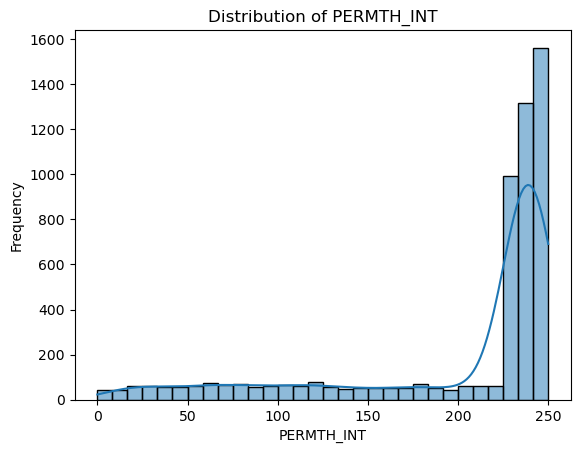

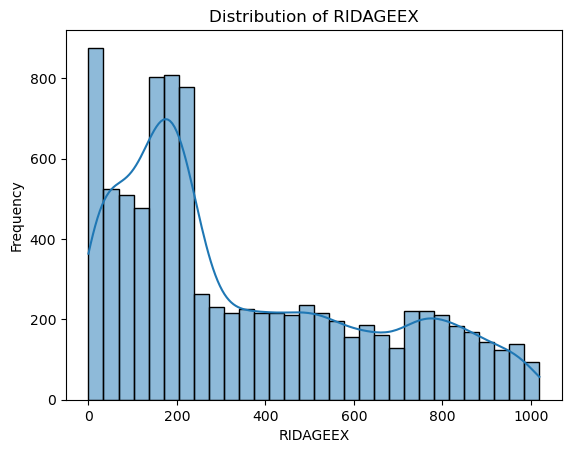

In [7]:
# ELIGSTAT, MORTSTAT, PERMTH_INT, AND RIDAGEEX are important variables. Are any of these skewed?

# count plots for ELIGSTAT and MORTSTAT along with histograms for PERMTH_INT and RIDAGEEX
sns.countplot(x='ELIGSTAT', data=df)
plt.title('Distribution of ELIGSTAT')
plt.xlabel('ELIGSTAT')
plt.ylabel('Count')
plt.show()

# value counts for ELIGSTAT
# 1 means eligible for mortality follow-up, 2 means under 18, 3 means ineligible
print(df['ELIGSTAT'].value_counts(dropna=False) )

sns.countplot(x='MORTSTAT', data=df)
plt.title('Distribution of MORTSTAT')
plt.xlabel('MORTSTAT')
plt.ylabel('Count')
plt.show()


# value counts for MORTSTAT
# 0 means alive, 1 means deceased, and NaNs are ineligible or under 18
print(df['MORTSTAT'].value_counts(dropna=False) )

sns.histplot(df['PERMTH_INT'], bins=30, kde=True)
plt.title('Distribution of PERMTH_INT')
plt.xlabel('PERMTH_INT')
plt.ylabel('Frequency')
plt.show()

sns.histplot(df['RIDAGEEX'], bins=30, kde=True)
plt.title('Distribution of RIDAGEEX')
plt.xlabel('RIDAGEEX')
plt.ylabel('Frequency')
plt.show()




- **2 of the 4 important variables mentioned in part 1 of the project instructions are skewed. PERMTH_INT is left skewed and RIDAGEEX is right skewed. This sort of makes sense as for PERMTH_INT represents the amount of time individuals survive and a lot of people cluster near the end, having long lives, while fewer pass away earlier. RIDAGEEX is simply showing that there are many younger participants in this data set with a long tail that goes into the older ages.**


In [ ]:
#Code to find outliers by IQR rule

import numpy as np

df["PERMTH_INT"] = pd.to_numeric(df["PERMTH_INT"], errors="coerce")
df["RIDAGEEX"] = pd.to_numeric(df["RIDAGEEX"], errors="coerce")

Q1_perm = df["PERMTH_INT"].quantile(0.25)
Q3_perm = df["PERMTH_INT"].quantile(0.75)
IQR_perm = Q3_perm - Q1_perm

lower_perm = Q1_perm - 1.5 * IQR_perm
upper_perm = Q3_perm + 1.5 * IQR_perm

perm_outliers = df[(df["PERMTH_INT"] < lower_perm) | 
                   (df["PERMTH_INT"] > upper_perm)]

print("PERMTH_INT outliers:", perm_outliers.shape[0])

Q1_age = df["RIDAGEEX"].quantile(0.25)
Q3_age = df["RIDAGEEX"].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[(df["RIDAGEEX"] < lower_age) | 
                  (df["RIDAGEEX"] > upper_age)]

print("RIDAGEEX outliers:", age_outliers.shape[0])

perm_outliers[["PERMTH_INT"]].head()


PERMTH_INT outliers: 883
RIDAGEEX outliers: 0


,PERMTH_INT
12,16.0
15,63.0
28,27.0
39,118.0
45,22.0


- **Out of the 4 important variables, MORTSTAT and ELIGSTAT are categorical so we only need to check PERMTH_INT and RIDAGEEX for outliers and we can see that, the age variable has 0 outliers and the survival time variable has a ton of outliers. This makes sense especially when converted to months, the age variable is well balanced with no extreme ages while the survival time variable shows 883 individuals who have extreme survival times. When we look at the head to see the actual individuals who were deemed outliers, most of the values are low such as 16, 22, 27, and 63 months which means these individuals probably died relatively soon after their interviews.**

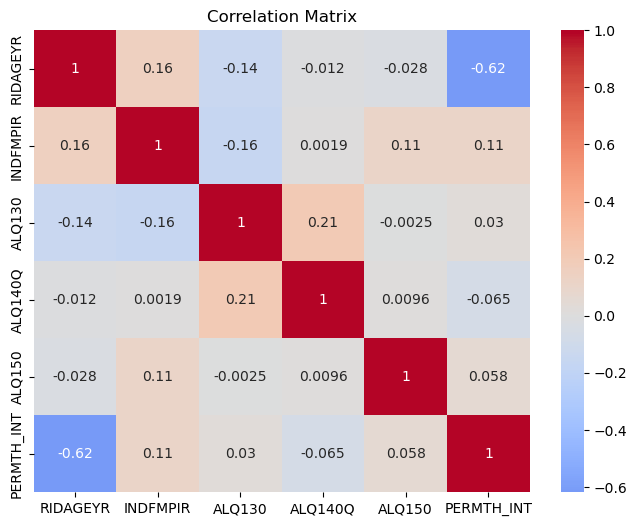

In [26]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

numeric_vars = [
    "RIDAGEYR",
    "INDFMPIR",
    "ALQ130",
    "ALQ140Q",
    "ALQ150",
    "PERMTH_INT"
]

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

 **When we pair numeric variables together, most correlations are rather mild with a few that stand out in the heatmap above.**
-  The strongest negative correlation, and correlation in general, is between RIDAGEYR and PERMTH_INT at -0.62. This logically makes sense. RIDAGEYR is the individual's age in years at examination time and PERMTH_INT is the survival time after the interview of that patient. This strong negative correlation is saying that older participants have less survival months which is expected and important to take into account because mortality risk increases with age. This negative correlation sort of just confirms the idea that age plays a large part in predicting mortality.
- The strongest positive correlation is only 0.21 and it is between ALQ130 and ALQ140Q which capture the average drinks per drinking day and drinking frequency, respectively. This makes sense because participants who drink more frequently are likely to have higher average consumption which reflects the positive correlation.
- When looking at RIDAGEYR compared to all of the ALQ variables, they all almost have no correlation which means that drinking patterns and drinking behavior have almost no correlation to how old an individual is, rather than following a trend, alcohol behavior varies across all different ages. This information comes into play when we look at the PERMTH_INT (survival time variable) compared to all of the ALQ variables, which again, are all very weak. This shows that alcohol behaviors don't have any strong linear relationship with survival time across all people. Alcohol may still have negative effects on mortality non linearly through long term diseases or sickness, but when compared to age, age has a much larger effect on mortality.

In [34]:
# Mortality x Gender
pd.crosstab(df["MORTSTAT"], df["RIAGENDR"], normalize="columns")

RIAGENDR,1.0,2.0
MORTSTAT,,
0.0,0.653454,0.726614
1.0,0.346546,0.273386


In [35]:
# Mortality x Race/Ethnicity
pd.crosstab(df["MORTSTAT"], df["RIDRETH1"], normalize="columns")

RIDRETH1,1.0,2.0,3.0,4.0,5.0
MORTSTAT,,,,,
0.0,0.764023,0.783383,0.62602,0.690821,0.766839
1.0,0.235977,0.216617,0.37398,0.309179,0.233161


In [36]:
# Gender x Race/Ethnicity
pd.crosstab(df["RIAGENDR"], df["RIDRETH1"], normalize="columns")

RIDRETH1,1.0,2.0,3.0,4.0,5.0
RIAGENDR,,,,,
1.0,0.496611,0.453311,0.492129,0.490126,0.469072
2.0,0.503389,0.546689,0.507871,0.509874,0.530928


**When we look at these contingency tables of our 3 categorical variables crosstabbed with each other, there are a couple of noticable patterns.**
- When crossing mortality and gender, we see that around 65% of males are alive and around 73% of females are alive which is a very noticeable 8% difference. This simply suggests that gender actually plays a rather significant part in mortality rate, associating men with higher mortality than women.
- The mortality rates by race are all fairly close together besides group 3 which the codebook classifies as white and this is a bit tricky to interpret. Intuitively, race shouldn't play too much of a part on mortality so this likely has more to do with the age demographic of participants in each group and more white participants being older which leads to higher mortality rates.
- The last contingency table simply shows the demographics of the participants and it is all fairly balanced indicating that the dataset doesn't have any sort of demographic imbalance.

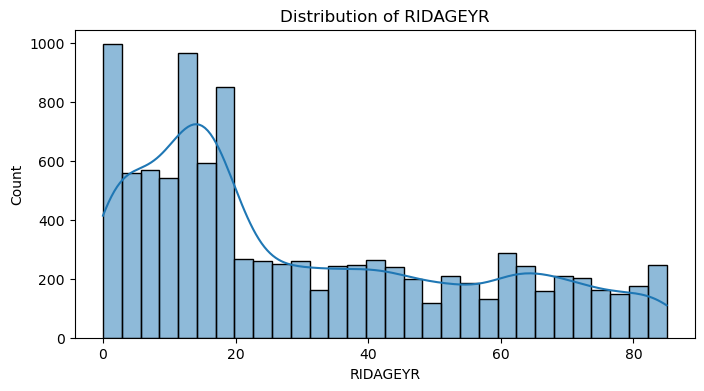

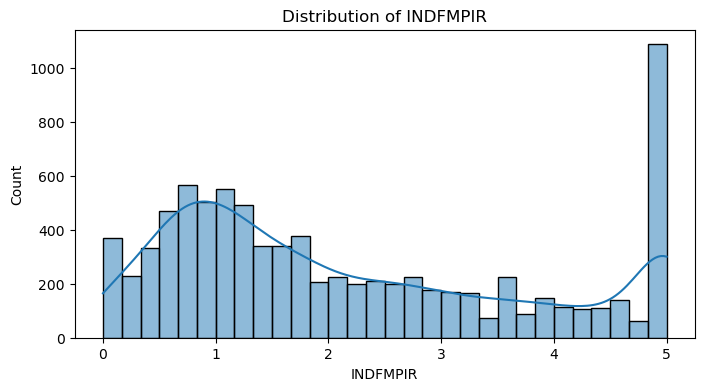

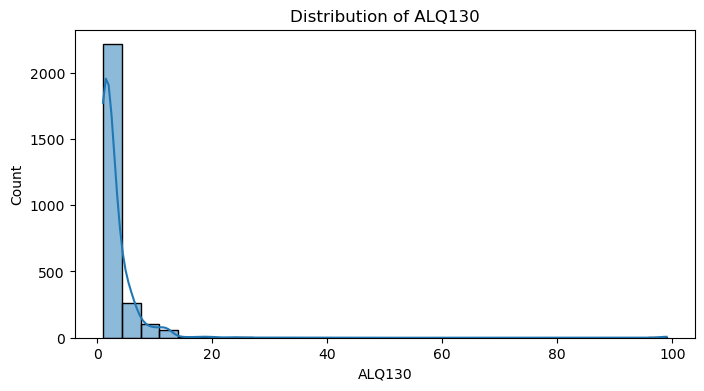

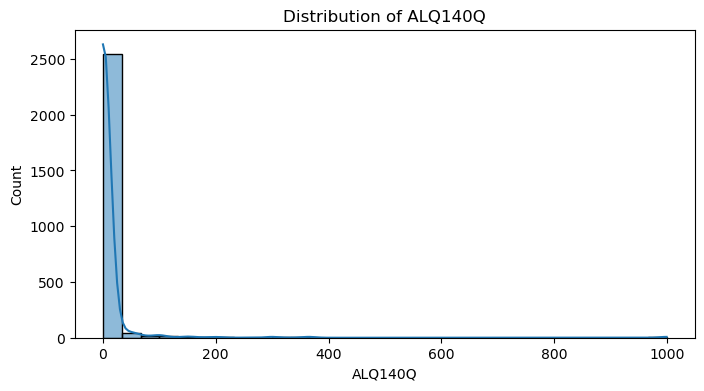

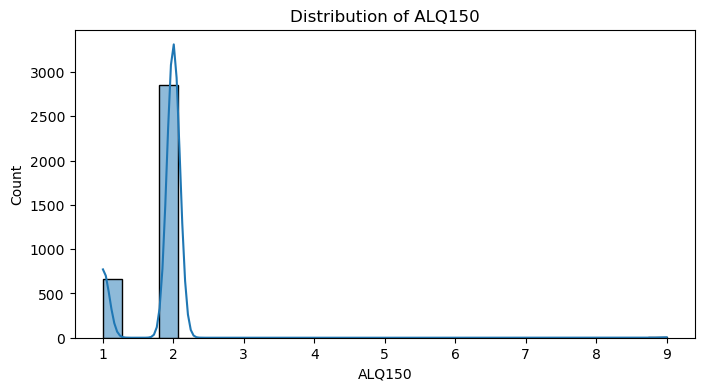

In [9]:
# visualize numeric variables
num_vars = ['RIDAGEYR', 'INDFMPIR', 'ALQ130', 'ALQ140Q', 'ALQ150']
for var in num_vars:
    plt.figure(figsize=(8,4))
    sns.histplot(df[var], kde=True, bins=30)
    plt.title(f"Distribution of {var}")
    plt.show()

# PART 2
 We restrict to adults 20+ and need to be eligible for mortality follow-up

In [10]:
# restrict to adults 20 and up and have to be eligible for mortality follow-up (ELIGSTAT=1)
df_adults = df[(df['RIDAGEYR'] >= 20) & (df['ELIGSTAT'] == 1)].copy()

# If no drinks in past year (ALQ100=2) OR no drinks in lifetime (ALQ110=2),
# the survey skips habits. We must set these habit variables to 0/No.
filler = (df_adults['ALQ100'] == 2) | (df_adults['ALQ110'] == 2)

df_adults.loc[filler, 'ALQ130'] = 0     # Avg drinks/day
df_adults.loc[filler, 'ALQ140Q'] = 0    # Binge drinking days
df_adults.loc[filler, 'ALQ150'] = 2     # Ever 5+ drinks daily (2 = No)

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# normalize numeric features using min-max scaling
def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

#Feature Selection
# Predictors: Age, Gender, Race, Poverty Income, Avg Drinks, Binge Days, Drinking History
features = ['RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'INDFMPIR', 'ALQ130', 'ALQ140Q', 'ALQ150']
targets = ['MORTSTAT', 'PERMTH_INT']

# take subset of the dataframe with only the selected features and targets
df_adults_subset = df_adults[features + targets].copy()
print(df_adults_subset.shape)
print(df_adults_subset.head())

# check for missing values in the subset dataframe
missing_values_subset = df_adults_subset.isnull().sum()
total_missing_subset = missing_values_subset.sum()
print(f"\nTotal missing values in subset dataframe: {total_missing_subset}")
print("\nMissing values in each column of subset dataframe:")
print(missing_values_subset)

(4877, 9)
    RIDAGEYR  RIAGENDR  RIDRETH1  INDFMPIR  ALQ130       ALQ140Q  ALQ150  \
1       77.0       1.0       3.0      5.00     1.0  5.397605e-79     2.0   
4       49.0       1.0       3.0      5.00     3.0  1.200000e+01     2.0   
6       59.0       2.0       4.0       NaN     0.0  0.000000e+00     2.0   
9       43.0       1.0       4.0       NaN     1.0  5.397605e-79     2.0   
11      37.0       1.0       3.0      4.93     3.0  1.000000e+00     1.0   

    MORTSTAT  PERMTH_INT  
1        1.0       177.0  
4        0.0       244.0  
6        0.0       237.0  
9        1.0       231.0  
11       0.0       236.0  

Total missing values in subset dataframe: 3814

Missing values in each column of subset dataframe:
RIDAGEYR         0
RIAGENDR         0
RIDRETH1         0
INDFMPIR       745
ALQ130        1175
ALQ140Q       1175
ALQ150         719
MORTSTAT         0
PERMTH_INT       0
dtype: int64


In [12]:
# drop missing values and filter out NHANES "refused/dontknow" codes (7,9,77,99,777,999)
df_final = df_adults_subset.dropna()
df_final = df_final[~df_final['ALQ130'].isin([77,99])]
df_final = df_final[~df_final['ALQ140Q'].isin([777,999])]
df_final = df_final[~df_final['ALQ150'].isin([7,9])]

#check missing values in final dataframe
missing_values_final = df_final.isnull().sum()
total_missing_final = missing_values_final.sum()
print(f"\nTotal missing values in final dataframe: {total_missing_final}")
print("\nMissing values in each column of final dataframe:")
print(missing_values_final)

#check shape
print(f"\nShape of final dataframe: {df_final.shape}")
print(df_final.head())


Total missing values in final dataframe: 0

Missing values in each column of final dataframe:
RIDAGEYR      0
RIAGENDR      0
RIDRETH1      0
INDFMPIR      0
ALQ130        0
ALQ140Q       0
ALQ150        0
MORTSTAT      0
PERMTH_INT    0
dtype: int64

Shape of final dataframe: (3180, 9)
    RIDAGEYR  RIAGENDR  RIDRETH1  INDFMPIR  ALQ130       ALQ140Q  ALQ150  \
1       77.0       1.0       3.0      5.00     1.0  5.397605e-79     2.0   
4       49.0       1.0       3.0      5.00     3.0  1.200000e+01     2.0   
11      37.0       1.0       3.0      4.93     3.0  1.000000e+00     1.0   
12      70.0       1.0       1.0      1.07     2.0  5.397605e-79     2.0   
13      81.0       1.0       3.0      2.67     1.0  5.397605e-79     2.0   

    MORTSTAT  PERMTH_INT  
1        1.0       177.0  
4        0.0       244.0  
11       0.0       236.0  
12       1.0        16.0  
13       1.0       137.0  


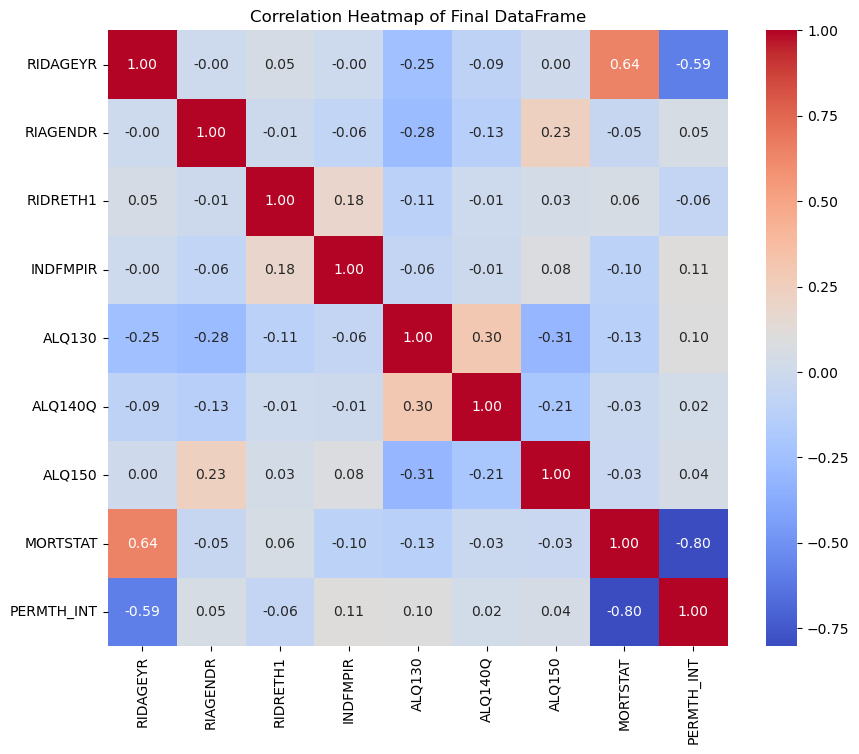

In [13]:
# correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_final.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Final DataFrame")
plt.show()

In [14]:
df_final.columns
#Mortstat classification; Permth_int regression

Index(['RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'INDFMPIR', 'ALQ130', 'ALQ140Q',
       'ALQ150', 'MORTSTAT', 'PERMTH_INT'],
      dtype='object')